In [57]:
# Carregando bibliotecas e base de dados
from ucimlrepo import fetch_ucirepo

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Perceptron
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import precision_recall_curve

In [2]:
# fetch dataset 
diabetes = fetch_ucirepo(id=296) 
  
# data (Pandas dataframes) 
X = diabetes.data.features

# Transformando em variável binária: 1 para readmissão em menos de 30 dias e 0 para os demais casos
y = diabetes.data.targets['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# metadata 
print(diabetes.metadata) 
  
# variable information 
print(diabetes.variables) 

{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide pro

/home/wagner/anaconda3/envs/ibge-v1/lib/python3.12/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [3]:
# Explorando as primerias linhas do dataset
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print(X.head(200))

# Verificando o tipo do dataset como dataframe do Pandas
type(X)

                race  gender       age weight  admission_type_id  \
0          Caucasian  Female    [0-10)    NaN                  6   
1          Caucasian  Female   [10-20)    NaN                  1   
2    AfricanAmerican  Female   [20-30)    NaN                  1   
3          Caucasian    Male   [30-40)    NaN                  1   
4          Caucasian    Male   [40-50)    NaN                  1   
5          Caucasian    Male   [50-60)    NaN                  2   
6          Caucasian    Male   [60-70)    NaN                  3   
7          Caucasian    Male   [70-80)    NaN                  1   
8          Caucasian  Female   [80-90)    NaN                  2   
9          Caucasian  Female  [90-100)    NaN                  3   
10   AfricanAmerican  Female   [40-50)    NaN                  1   
11   AfricanAmerican    Male   [60-70)    NaN                  2   
12         Caucasian  Female   [40-50)    NaN                  1   
13         Caucasian    Male   [80-90)    NaN   

pandas.core.frame.DataFrame

In [4]:
# Dando uma geral no dataset
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    3197 non-null    object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                61510 non-null   object
 9   medical_specialty         51817 non-null   object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         101766 non-null  int64 
 14  numb

In [5]:
display(X.isnull().sum())

# Percentual de nulos por coluna
display(X.isna().sum() / X.shape[0])

race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide                   0
glipizide                       0
glyburide     

race                        0.022336
gender                      0.000000
age                         0.000000
weight                      0.968585
admission_type_id           0.000000
discharge_disposition_id    0.000000
admission_source_id         0.000000
time_in_hospital            0.000000
payer_code                  0.395574
medical_specialty           0.490822
num_lab_procedures          0.000000
num_procedures              0.000000
num_medications             0.000000
number_outpatient           0.000000
number_emergency            0.000000
number_inpatient            0.000000
diag_1                      0.000206
diag_2                      0.003518
diag_3                      0.013983
number_diagnoses            0.000000
max_glu_serum               0.947468
A1Cresult                   0.832773
metformin                   0.000000
repaglinide                 0.000000
nateglinide                 0.000000
chlorpropamide              0.000000
glimepiride                 0.000000
a

Coluna Weight tem 96% de dados nulos, o que implica que remover todas essas linhas inviabilizaria o treinamento do modelo. Como o peso é uma variável importante no controle da glicose, seria imprudente colocar um valor mediano ou outras formas estatísticas.
Imputar média/mediana vai basicamente criar uma coluna quase constante. O modelo pode aprender ruído. Pode até prejudicar a performance.
Decidi remover a coluna devido ao número alto de valores nulos, evitando ruído e nao distorcendo a distribuíçao.

In [6]:
cat_unknown = ['medical_specialty', 'payer_code']
cat_not_measured = ['A1Cresult', 'max_glu_serum']

In [7]:
# Removendo a coluna 'weight' por conter mais de 96% de valores nulos e criando o indicador de ausência de peso
X['weight_missing'] = X['weight'].isna().astype(int)
X = X.drop(columns=['weight'], axis=1)

# Preenchendo os valores nulos das colunas 'A1Cresult' e 'max_glu_serum' com a categoria 'NotMeasured'
X['A1Cresult'] = X['A1Cresult'].fillna('NotMeasured')
X['max_glu_serum'] = X['max_glu_serum'].fillna('NotMeasured')

# Preenchendo os valores nulos das colunas 'medical_specialty' e 'payer_code' com a categoria 'Unknown'
X['medical_specialty'] = X['medical_specialty'].fillna('Unknown')
X['payer_code'] = X['payer_code'].fillna('Unknown')

# Criando listas de colunas categóricas para cada tipo de tratamento de valores nulos
null_cats = ['diag_1', 'diag_2', 'diag_3', 'race']

# Removendo as linhas com valores nulos nas colunas de diagnóstico e race
X = X.dropna(subset=null_cats)
y = y.loc[X.index]  # MUITO IMPORTANTE alinhar o target

/tmp/ipykernel_26807/3499769051.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['weight_missing'] = X['weight'].isna().astype(int)


In [ ]:
# Confirmando que não há mais valores nulos
display(X.isna().sum() / X.shape[0])

race                        0.0
gender                      0.0
age                         0.0
admission_type_id           0.0
discharge_disposition_id    0.0
admission_source_id         0.0
time_in_hospital            0.0
payer_code                  0.0
medical_specialty           0.0
num_lab_procedures          0.0
num_procedures              0.0
num_medications             0.0
number_outpatient           0.0
number_emergency            0.0
number_inpatient            0.0
diag_1                      0.0
diag_2                      0.0
diag_3                      0.0
number_diagnoses            0.0
max_glu_serum               0.0
A1Cresult                   0.0
metformin                   0.0
repaglinide                 0.0
nateglinide                 0.0
chlorpropamide              0.0
glimepiride                 0.0
acetohexamide               0.0
glipizide                   0.0
glyburide                   0.0
tolbutamide                 0.0
pioglitazone                0.0
rosiglit

In [25]:
#total de observações após remoção de nulos
print(f'Total de observações após remoção de nulos: {X.shape[0]}')

Total de observações após remoção de nulos: 98053


In [9]:
numeric_cols = X.select_dtypes(include=['int64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

In [10]:
# Criando pipelines separados para as colunas categóricas com tratamento de valores nulos
cat_unknown_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Criando pipelines separados para as colunas categóricas com tratamento de valores nulos
cat_not_measured_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='NotMeasured')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [11]:
# Utilizando o ColumnTransformer para aplicar as transformações necessárias em cada tipo de variável
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat_unknown', cat_unknown_pipeline, cat_unknown),
        ('cat_not_measured', cat_not_measured_pipeline, cat_not_measured),
        # handle_unknown='ignore' é necessário para evitar erros caso haja categorias no conjunto de teste que não estejam presentes no conjunto de treino
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [12]:
# Criando o pipeline com o pré-processamento e o modelo de classificação com Perceptron
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', Perceptron(class_weight='balanced', random_state=42, max_iter=1000))
])

In [13]:
# Analisando a distribuição da variável alvo
display(y.value_counts())

# Analisando as proporções da variável alvo
display(y.value_counts(normalize=True))

readmitted
0    86987
1    11066
Name: count, dtype: int64

readmitted
0    0.887143
1    0.112857
Name: proportion, dtype: float64

In [14]:
# Verificando o formato dos dados
display(X.shape)
# Verificando o formato da variável alvo
display(y.shape)
display(y.head())
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Treinando com Perceptron
display(model.fit(x_train, y_train))

# Fazendo previsões
y_hat_train = model.predict(x_train)
y_hat_test = model.predict(x_test)

print("Acurácia no conjunto de treino: ", accuracy_score(y_train, y_hat_train))
print("Acurácia no conjunto de teste: ", accuracy_score(y_test, y_hat_test))

print("-"*100)

y_pred = model.predict(x_test)

print("Matriz de confusão (Perceptron):")
print(confusion_matrix(y_test, y_pred))
print("-"*100)
print("Classification Report (Perceptron):")
print(classification_report(y_test, y_pred))

(98053, 47)

(98053,)

1    0
2    0
3    0
4    0
5    0
Name: readmitted, dtype: int64

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_unknown', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Acurácia no conjunto de treino:  0.45988315340122676
Acurácia no conjunto de teste:  0.44832744084851783
----------------------------------------------------------------------------------------------------
Matriz de confusão (Perceptron):
[[10830 15266]
 [  962  2358]]
----------------------------------------------------------------------------------------------------
Classification Report (Perceptron):
              precision    recall  f1-score   support

           0       0.92      0.42      0.57     26096
           1       0.13      0.71      0.23      3320

    accuracy                           0.45     29416
   macro avg       0.53      0.56      0.40     29416
weighted avg       0.83      0.45      0.53     29416



In [ ]:
# Treinando o modelo

# O modelo agora está detectando 71% dos pacientes readmitidos
# Accuracy caiu para 45%
# Muitos falsos positivos (15266)
# O modelo está dizendo que muita gente vai ser readmitida quando não vai.
# Normalmente em saúde:
# Recall alto é mais importante que precisão.
# Porque perder um paciente de risco pode gerar custo e complicação clínica.


# Criando o pipeline com o pré-processamento e o modelo de classificação com Perceptron
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
# Treinando o modelo de regressão logística
model.fit(x_train, y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_unknown', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [16]:
# Fazendo previsões

y_hat_train = model.predict(x_train)
y_hat_test = model.predict(x_test)

In [17]:
print(y_hat_train[:5])
print(y_train.head())

[0 1 1 0 0]
50007    0
80028    0
32855    1
25454    0
98282    0
Name: readmitted, dtype: int64


In [18]:
print("Acurácia no conjunto de treino: ", accuracy_score(y_train, y_hat_train))
print("Acurácia no conjunto de teste: ", accuracy_score(y_test, y_hat_test))

Acurácia no conjunto de treino:  0.6643064236490522
Acurácia no conjunto de teste:  0.6406377481642643


In [19]:
y_pred = model.predict(x_test)

print("-"*100)
print("Matriz de confusão (Regressão Logística):")
print(confusion_matrix(y_test, y_pred))
print("-"*100)
print("Classification Report (Regressão Logística):")
print(classification_report(y_test, y_pred))

----------------------------------------------------------------------------------------------------
Matriz de confusão (Regressão Logística):
[[17095  9001]
 [ 1570  1750]]
----------------------------------------------------------------------------------------------------
Classification Report (Regressão Logística):
              precision    recall  f1-score   support

           0       0.92      0.66      0.76     26096
           1       0.16      0.53      0.25      3320

    accuracy                           0.64     29416
   macro avg       0.54      0.59      0.51     29416
weighted avg       0.83      0.64      0.71     29416



# Análise técnica dos modelos
* Perceptron
    * Modelo linear simples
    * Recall alto (71%)
    * Muitos falsos positivos
    * Acurácia baixa (44%)
* Regressao Logística
    * Modelo linear probabilístico, mais estável
    * class_weight=balanced funciona muito melhor
    * Recall da classe 1 em 53%
    * Permite ajustar limiar de decisao
    * Muito mais apropriado para problemas de desbalanceamento

Embora o Perceptron apresente Recall de 71%, a acurácia ficou muito baixa (44%).
O número de falso-positivos aprensentou um número muito alto (15266)

A Regressão Logística, ao utilizar class_weight='balanced', apresenta um resultado melhor,
apesar do recall da classe 1 ficar em 53%, reduzindo substancialmente o valor de falsos-positivo (9001)

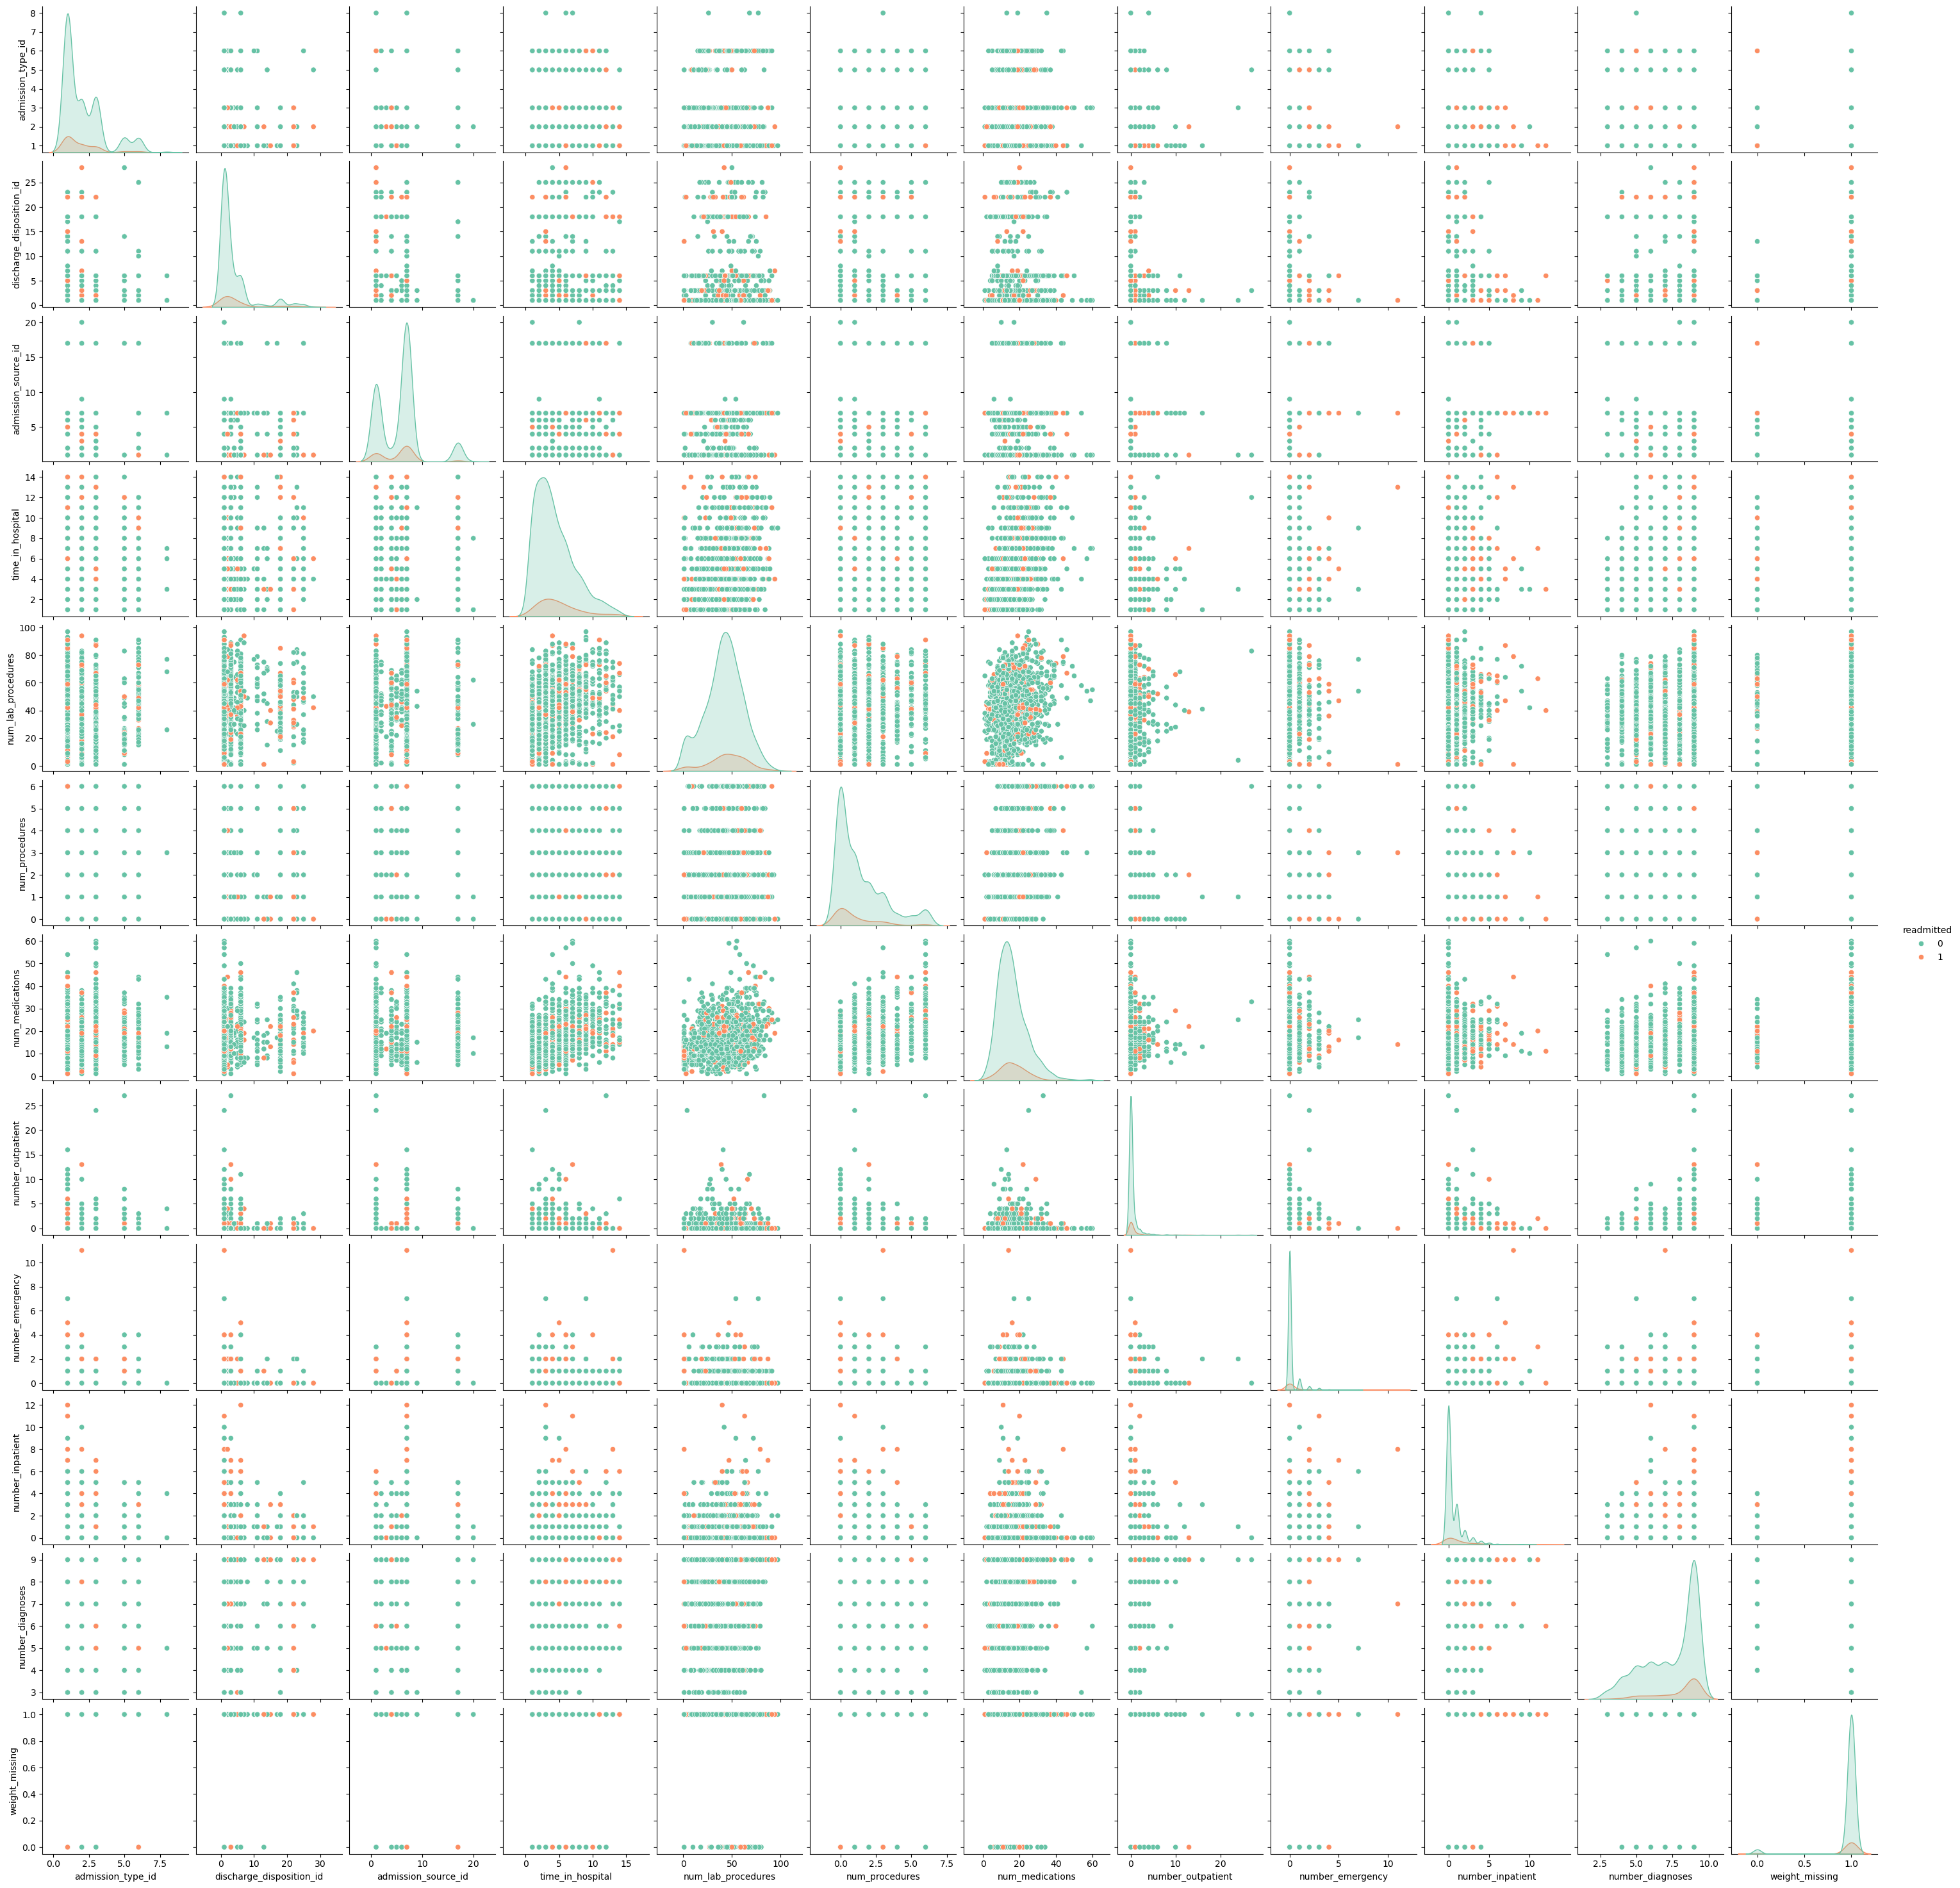

In [20]:
# Pairplot para analisar as relações entre as variáveis numéricas
df_plot = X.copy()
df_plot['readmitted'] = y.astype(str)
sns.pairplot(df_plot.sample(1500),
             vars=numeric_cols,
             diag_kind='kde',
             hue='readmitted',
             palette='Set2')

In [21]:
# Testando com KNN

knn_model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=3))
])

knn_model.fit(x_train, y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat_unknown', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
y_hat_train = knn_model.predict(x_train)
y_hat_test = knn_model.predict(x_test)

In [23]:
print("Acurácia no conjunto de treino: ", accuracy_score(y_train, y_hat_train))
print("Acurácia no conjunto de teste: ", accuracy_score(y_test, y_hat_test))

Acurácia no conjunto de treino:  0.9066538455934846
Acurácia no conjunto de teste:  0.8625577916779984


In [24]:
print("-"*100)
print("Matriz de confusão (KNN):")
print(confusion_matrix(y_test, y_hat_test))
print("-"*100)
print("Classification Report (KNN):")
print(classification_report(y_test, y_hat_test))

----------------------------------------------------------------------------------------------------
Matriz de confusão (KNN):
[[25111   985]
 [ 3058   262]]
----------------------------------------------------------------------------------------------------
Classification Report (KNN):
              precision    recall  f1-score   support

           0       0.89      0.96      0.93     26096
           1       0.21      0.08      0.11      3320

    accuracy                           0.86     29416
   macro avg       0.55      0.52      0.52     29416
weighted avg       0.81      0.86      0.83     29416



# _Comparaçao dos Modelos:_

* KNN
    * Tem acurácia alta
    * Ignora completamente a classe minoritária
    * Recall muito baixo (Detecta apenas 8% dos pacientes de risco)
    * Muitas features categóricas explodem dimensionalidade
---
    Está favorecendo a classe majoritária
---
* Perceptron (balanceada)
    * Acurária baixa
    * Recall muito alto baixo
    * Muitos falsos-positivos
---
    Recall altíssimo (0.71), mas gera falsos-positivos demais.
---
* Regressao Logística (balanceada)
    * Acurácia aceitável
    * Recall razoável
    * Melhor F1-score da classe 1

    ### Melhor até agora
---
* Accuracy pode ser enganosa em datasets desbalanceados 
* Modelos não balanceados favorecem a classe majoritária 
* Ajuste de class_weight muda completamente o comportamento do modelo
---

In [ ]:
# Pegando as probabilidades preditas para a classe 1 (readmitidos em menos de 30 dias)
y_prob = model.predict_proba(x_test)[:, 1]

In [61]:
# Testando diferentes thresholds para a classificação
# O threshold padrão é 0.5, ou seja, se a probabilidade predita for maior ou igual a 0.5, 
# o modelo classifica como 1 (readmitido), caso contrário, classifica como 0 (não readmitido).
# O melhor threshold depende do trade-off entre precisão e recall que queremos alcançar, 
# e pode ser ajustado de acordo com as necessidades do problema em questão.
# O threshold de 0.60 é o que apresenta melhor equilíbrio entre precisão e recall para a classe 1

# Em contexto hospitalar normalmente o recall é mais importante que a precisão, pois perder 
# um paciente de risco pode gerar custo e complicação clínica.
# Apesar do threshold de 0.50 apresentar F1 score ligeiramente mais alto, a precisao cai para 0.163
# O threshold de 0.60 é o que apresenta melhor equilíbrio entre precisão e recall e F1 score para a classe 1

# O threshold de 0.45 apresenta um recall de 0.648, mas a precisão cai para 0.152. Buscando um balanceado com F1 score

thresholds = np.arange(0.05, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_adj = (y_prob >= t).astype(int)
    
    recall = recall_score(y_test, y_pred_adj)
    precision = precision_score(y_test, y_pred_adj)
    f1 = f1_score(y_test, y_pred_adj)
    
    results.append((t, recall, precision, f1))

for r in results:
    print(f"Threshold: {r[0]:.2f} | Recall: {r[1]:.3f} | Precision: {r[2]:.3f} | F1: {r[3]:.3f}")

Threshold: 0.05 | Recall: 0.999 | Precision: 0.113 | F1: 0.203
Threshold: 0.10 | Recall: 0.996 | Precision: 0.114 | F1: 0.204
Threshold: 0.15 | Recall: 0.984 | Precision: 0.114 | F1: 0.205
Threshold: 0.20 | Recall: 0.972 | Precision: 0.116 | F1: 0.207
Threshold: 0.25 | Recall: 0.949 | Precision: 0.119 | F1: 0.211
Threshold: 0.30 | Recall: 0.904 | Precision: 0.123 | F1: 0.217
Threshold: 0.35 | Recall: 0.837 | Precision: 0.130 | F1: 0.224
Threshold: 0.40 | Recall: 0.749 | Precision: 0.139 | F1: 0.235
Threshold: 0.45 | Recall: 0.648 | Precision: 0.152 | F1: 0.246
Threshold: 0.50 | Recall: 0.527 | Precision: 0.163 | F1: 0.249
Threshold: 0.55 | Recall: 0.418 | Precision: 0.182 | F1: 0.254
Threshold: 0.60 | Recall: 0.317 | Precision: 0.203 | F1: 0.248
Threshold: 0.65 | Recall: 0.226 | Precision: 0.220 | F1: 0.223
Threshold: 0.70 | Recall: 0.159 | Precision: 0.249 | F1: 0.194
Threshold: 0.75 | Recall: 0.109 | Precision: 0.291 | F1: 0.158
Threshold: 0.80 | Recall: 0.071 | Precision: 0.335 | F1

In [54]:
# Filtrando os resultados para identificar os thresholds que apresentam recall maior ou igual a 0.60
filtered = [r for r in results if r[1] >= 0.60 and r[3] >= 0.24]
filtered

[(np.float64(0.45),
  0.6475903614457831,
  0.15182543605677565,
  0.24598135118128253)]

In [55]:
best_threshold = 0.45

y_final = (y_prob >= best_threshold).astype(int)

print(classification_report(y_test, y_final))

              precision    recall  f1-score   support

           0       0.92      0.54      0.68     26096
           1       0.15      0.65      0.25      3320

    accuracy                           0.55     29416
   macro avg       0.54      0.59      0.46     29416
weighted avg       0.84      0.55      0.63     29416



Recall = 0.65 (bem alto)

* F1 = 0.246 (praticamente igual aos outros)

* Captura muito mais pacientes de risco

* A precisão é baixa (0.15), mas isso é esperado com base desbalanceada.

In [65]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * (precision * recall) / (precision + recall)
best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]
print("Best threshold:", best_threshold)

display(thresholds)

Best threshold: 0.9928781927296706


/tmp/ipykernel_26807/2967706627.py:3: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)


array([0.00355678, 0.00397867, 0.00408018, ..., 0.99582372, 0.9998156 ,
       0.99984754], shape=(29416,))

In [ ]:
# Aplicando o melhor threshold encontrado
y_final = (y_prob >= 0.45).astype(int)

print(classification_report(y_test, y_final))

              precision    recall  f1-score   support

           0       0.92      0.54      0.68     26096
           1       0.15      0.65      0.25      3320

    accuracy                           0.55     29416
   macro avg       0.54      0.59      0.46     29416
weighted avg       0.84      0.55      0.63     29416



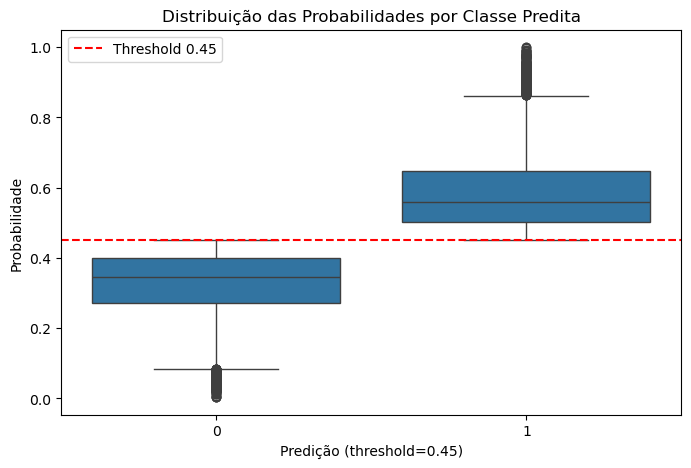

In [68]:
threshold = 0.45

# Probabilidades da classe 1
y_prob = model.predict_proba(x_test)[:, 1]

# Classificação com novo threshold
y_pred_new = (y_prob >= threshold).astype(int)

# Criar DataFrame
df_plot = pd.DataFrame({
    "Probabilidade": y_prob,
    "Predição (threshold=0.45)": y_pred_new
})

# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x="Predição (threshold=0.45)", y="Probabilidade", data=df_plot)
plt.axhline(threshold, color='red', linestyle='--', label='Threshold 0.45')
plt.legend()
plt.title("Distribuição das Probabilidades por Classe Predita")
plt.show()

* Classe 0 predita → probabilidades concentradas abaixo de 0.45

* Classe 1 predita → probabilidades acima de 0.45

* A linha vermelha está exatamente no ponto de decisão

Isso confirma que o threshold está sendo aplicado corretamente.

Observe:

* A mediana da classe 1 está por volta de 0.55–0.60

* A mediana da classe 0 está ~0.35

* Há separação, mas não é enorme, por isso o recall e precision não são muito altos.

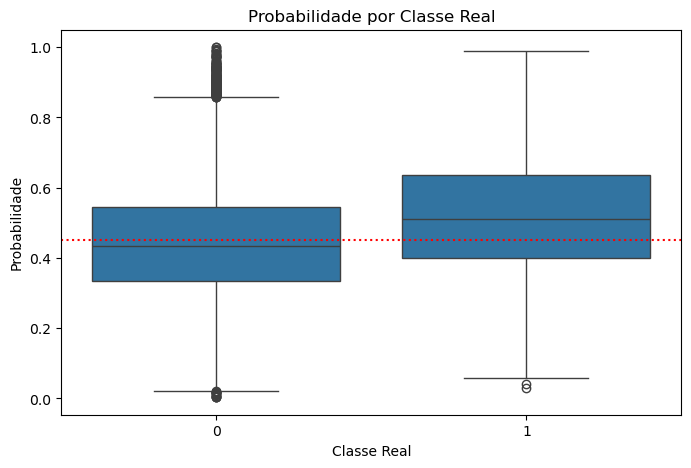

In [71]:
df_plot = pd.DataFrame({
    "Probabilidade": y_prob,
    "Classe Real": y_test
})

plt.figure(figsize=(8,5))
sns.boxplot(x="Classe Real", y="Probabilidade", data=df_plot)
plt.axhline(threshold, color='red', linestyle=':')
plt.title("Probabilidade por Classe Real")
plt.show()

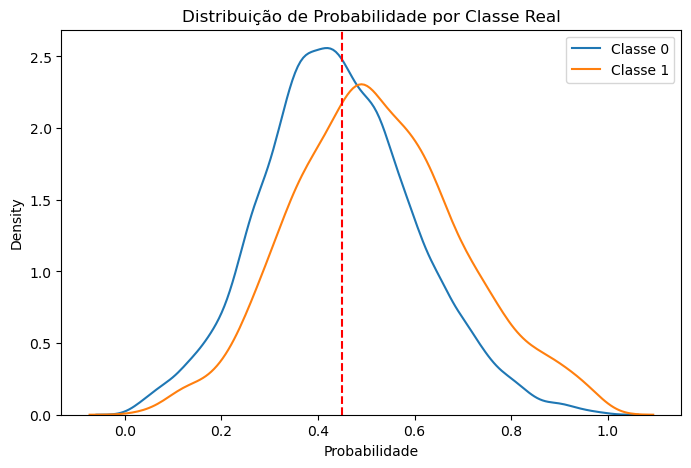

In [72]:
plt.figure(figsize=(8,5))

sns.kdeplot(df_plot[df_plot["Classe Real"]==0]["Probabilidade"], label="Classe 0")
sns.kdeplot(df_plot[df_plot["Classe Real"]==1]["Probabilidade"], label="Classe 1")

plt.axvline(threshold, color='red', linestyle='--')
plt.title("Distribuição de Probabilidade por Classe Real")
plt.legend()
plt.show()

In [ ]:
# minuto 56 video 3. separar treino e teste antes de fazer qualquer análise exploratória.